### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.70083868, 0.23067924, 0.2386322 , 0.28975343, 0.46956513,
       0.54373666, 0.52895317, 0.12844007, 0.18538455, 0.66106191,
       0.51524159, 0.74905164, 0.05086274, 0.0181161 , 0.19313351,
       0.8899808 , 0.86277152, 0.52476066, 0.03646791, 0.15315477])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 10)

coefs = [1, 1, 1, 1, 1, 1]
vessel_motion_calibration_coefficient = 1e-06 #  for vessel's force on pipe   ### !!! ### !!! ### !!! ###

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.97068629,  0.        ,  0.18369991],
        [ 0.        ,  1.        , -0.64485892],
        [-0.24035002,  0.        ,  0.74189711]],

       [[ 0.8136067 ,  0.        ,  0.56601469],
        [ 0.        ,  1.        , -0.22863883],
        [-0.58141563,  0.        ,  0.79205534]],

       [[ 0.76457458,  0.        ,  0.62627055],
        [ 0.        ,  1.        , -0.23637381],
        [-0.64453526,  0.        ,  0.74290822]],

       [[ 0.79006626,  0.        ,  0.58746726],
        [ 0.        ,  1.        , -0.28571594],
        [-0.61302146,  0.        ,  0.75713183]],

       [[ 0.7921572 ,  0.        ,  0.54425953],
        [ 0.        ,  1.        , -0.45249852],
        [-0.61031711,  0.        ,  0.70641819]],

       [[ 0.85160883,  0.        ,  0.44858172],
        [ 0.        ,  1.        , -0.51733736],
        [-0.52417784,  0.        ,  0.72879112]],

       [[ 0.96986627,  0.        ,  0.2103413 ],
        [ 0.        ,  1.        , -0.50462985],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-1.14598522e-01,  0.00000000e+00,  2.92282167e-01],
        [ 0.00000000e+00,  0.00000000e+00, -3.03040506e-01],
        [-4.62821736e-01,  0.00000000e+00, -3.35775107e-01]],

       [[-1.56358672e-01,  0.00000000e+00,  9.63820987e-02],
        [ 0.00000000e+00,  0.00000000e+00, -8.54063162e-01],
        [-2.18801246e-01,  0.00000000e+00, -3.15414431e-01]],

       [[-1.70072494e-02,  0.00000000e+00,  1.35595267e-02],
        [ 0.00000000e+00,  0.00000000e+00, -3.85439269e-02],
        [-2.01747079e-02,  0.00000000e+00, -2.36943224e-02]],

       [[-1.13147361e-01,  0.00000000e+00,  1.19583533e-01],
        [ 0.00000000e+00,  0.00000000e+00, -1.10318299e-01],
        [-1.45825094e-01,  0.00000000e+00, -1.34416627e-01]],

       [[-3.29501149e-01,  0.00000000e+00,  2.40295515e-01],
        [ 0.00000000e+00,  0.00000000e+00, -4.55587179e-01],
        [-4.27673916e-01,  0.00000000e+00, -4.76963443e-01]],

       [[-1.92827152e-01,  0.00000000e+00,  1.20414916e-01],
        [ 0.00

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.44509815,  0.26537626,  0.14793978],
       [ 1.22896053,  0.06082234,  0.21084538],
       [ 0.43194203, -0.12519423,  0.45084246],
       [ 0.36175348,  0.05286744,  0.27844408],
       [ 0.47056507,  0.48512415, -0.22631015],
       [ 0.50237008,  0.32336671, -0.22277894],
       [ 0.66496009,  0.7259795 ,  0.0271821 ],
       [ 0.78422847, -0.02890723,  0.02585976],
       [ 0.44135394,  0.14559998,  0.93855407],
       [ 0.25603484,  0.73072561, -0.06091032],
       [ 0.34174191,  0.52919439,  0.23303262],
       [ 0.78204335,  0.05036634,  0.47903835],
       [ 0.94220351,  0.26519854, -0.0588995 ],
       [ 0.97369059,  0.56637355, -0.33748824],
       [ 0.13324556,  0.11705581,  0.77702923],
       [ 0.72826429, -0.32080251,  0.3492529 ],
       [ 0.12431957,  0.3054524 , -0.09509583],
       [ 0.7665669 ,  0.34965424, -0.56056455],
       [ 0.94563706,  0.41378194,  0.44083453],
       [ 0.23878295,  0.47933647,  0.33072615]])

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.62550302, -0.16668578, -0.13818422],
       [ 1.25426039, -0.60939899, -0.33493357],
       [ 0.53565831,  0.51381468,  0.26896974],
       [ 1.26339944,  0.00679285, -0.11097301],
       [ 0.58934218,  0.14687578,  0.05982183],
       [ 0.31053057,  0.54038735,  0.01590296],
       [ 0.60548746,  0.02923741, -0.73720381],
       [ 0.71879601,  0.19651861, -0.36246406],
       [ 0.77910904,  0.5949226 ,  0.019861  ],
       [ 0.35908892, -0.06531929,  0.14226548],
       [ 0.59799927,  0.02100707, -0.34781256],
       [ 0.50313591, -0.53157082, -0.5967532 ],
       [ 0.44463379, -0.36209183,  0.22655285],
       [ 0.76274516,  0.31390974, -0.87010744],
       [ 1.02692189,  0.2064238 ,  0.42242689],
       [ 0.45753099, -0.62427118, -0.58237334],
       [ 0.58271815, -0.53206244,  0.25066297],
       [ 0.10966507,  0.13208806, -0.31269435],
       [ 0.55099567, -0.3961464 ,  0.05147275],
       [ 0.91712134,  0.68705993, -0.15505943]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.81710489, 0.43751956, 0.93245485],
       [0.64233346, 0.55826617, 0.96937169],
       [0.55674602, 0.47198496, 0.41389477],
       [0.58619488, 0.87006566, 0.98635938],
       [0.40388098, 0.77373433, 0.35890468],
       [0.89149988, 0.89523667, 0.76435136],
       [0.6545336 , 0.38578168, 0.68957032],
       [0.72459112, 0.52589519, 0.24205935],
       [0.14359182, 0.86893923, 0.77733256],
       [0.47496851, 0.48409758, 0.27797615],
       [0.4896735 , 0.37614252, 0.43830758],
       [0.47871607, 0.16534413, 0.07810152],
       [0.32053399, 0.48018949, 0.31940544],
       [0.4217145 , 0.14432761, 0.5411561 ],
       [0.57648253, 0.39576132, 0.3533076 ],
       [0.11363982, 0.09977528, 0.20173393],
       [0.0375895 , 0.47844767, 0.96777162],
       [0.8053981 , 0.66599285, 0.793045  ],
       [0.41499838, 0.91924728, 0.99193905],
       [0.83951031, 0.41344381, 0.33502767]])

In [44]:
theta(φ,θ,ψ)

array([[0.70083868, 0.24272643, 0.25102662],
       [0.23067924, 0.62046755, 0.65598822],
       [0.2386322 , 0.70041529, 0.32619424],
       [0.28975343, 0.65987925, 0.94485302],
       [0.46956513, 0.65646084, 0.53391499],
       [0.54373666, 0.5517494 , 0.41481422],
       [0.52895317, 0.246115  , 0.63245486],
       [0.12844007, 0.94265519, 0.82450329],
       [0.18538455, 0.10459639, 0.71335112],
       [0.66106191, 0.24238426, 0.69254406],
       [0.51524159, 0.8208374 , 0.33651473],
       [0.74905164, 0.36087407, 0.24027797],
       [0.05086274, 0.57709435, 0.69209586],
       [0.0181161 , 0.7040741 , 0.52157442],
       [0.19313351, 0.08221384, 0.9608563 ],
       [0.8899808 , 0.41751726, 0.3561569 ],
       [0.86277152, 0.68770563, 0.89389589],
       [0.52476066, 0.63818459, 0.05999202],
       [0.03646791, 0.33491588, 0.75660067],
       [0.15315477, 0.62513926, 0.23199253]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 1.01050205, -0.24239637,  0.23180249],
       [ 0.9559642 , -0.02245093,  0.31807833],
       [ 0.65563598,  0.25327202,  0.05984247],
       [ 1.00603956,  0.32441642,  0.08173469],
       [ 0.51952595,  0.63268837, -0.04616542],
       [ 0.93221321,  0.30055991, -0.39540247],
       [ 0.81227733, -0.03402135,  0.26056172],
       [ 0.71766435,  0.36545115, -0.20697974],
       [ 0.68020476,  0.75770381,  0.38705644],
       [ 0.53544458,  0.35697619, -0.00225399],
       [ 0.59752524,  0.16998991,  0.1798843 ],
       [ 0.48359705,  0.12936744, -0.01041625],
       [ 0.42431739,  0.37955333,  0.12078489],
       [ 0.4883437 , -0.0771813 ,  0.4279571 ],
       [ 0.64611366,  0.203181  ,  0.05107174],
       [ 0.13303971,  0.07689958,  0.18811625],
       [ 0.47861756,  0.44207819,  0.84118807],
       [ 0.97275411,  0.09412293, -0.06557991],
       [ 0.97344831,  0.51930891,  0.22048677],
       [ 0.85866664,  0.16407729, -0.13239729]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.97876271, -0.09098296,  0.18369991],
        [ 0.1898514 ,  0.74034683, -0.64485892],
        [-0.07733047,  0.66603955,  0.74189711]],

       [[ 0.72582125, -0.39091033,  0.56601469],
        [ 0.59378608,  0.77145472, -0.22863883],
        [-0.34727743,  0.50204256,  0.79205534]],

       [[ 0.77307707, -0.10068292,  0.62627055],
        [ 0.31135971,  0.9204252 , -0.23637381],
        [-0.55263639,  0.37773058,  0.74290822]],

       [[ 0.60481326, -0.53766452,  0.58746726],
        [ 0.77662833,  0.56143997, -0.28571594],
        [-0.17620827,  0.62904851,  0.75713183]],

       [[ 0.82244951, -0.16540367,  0.54425953],
        [ 0.45382583,  0.76765044, -0.45249852],
        [-0.34295615,  0.61915622,  0.70641819]],

       [[ 0.88867455, -0.09503672,  0.44858172],
        [ 0.34489701,  0.78320375, -0.51733736],
        [-0.30216484,  0.61445904,  0.72879112]],

       [[ 0.85495078, -0.47414733,  0.2103413 ],
        [ 0.51034074,  0.69634836, -0.50462985],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[ 0.06760549, -0.66280697,  0.25175507],
       [ 0.24088465, -0.29426764,  0.00985318],
       [ 0.21620266, -0.11078259, -0.16449171],
       [-0.08327968, -0.45807226,  0.45355788],
       [ 0.07880936, -0.20121006,  0.34508753],
       [ 0.24221545, -0.48074128,  0.28055446],
       [-0.20494714, -0.18322575,  0.29703994],
       [ 0.00456395,  0.09445646, -0.21887689],
       [-0.60999344, -0.10287324,  0.2276769 ],
       [-0.23090367, -0.03816854,  0.46100814],
       [ 0.35383532, -0.33472191, -0.10805343],
       [ 0.03191649, -0.10738833,  0.03171631],
       [-0.09174183,  0.04271141,  0.02785427],
       [ 0.32022548, -0.02747338, -0.2422195 ],
       [-0.40177311,  0.43727378,  0.16574546],
       [ 0.04395769, -0.20017801,  0.0742437 ],
       [ 0.05548869, -1.00599969,  0.49519164],
       [ 0.66270333, -0.57697701, -0.18848544],
       [-0.34055114,  0.01068839,  0.13257155],
       [ 0.15777165, -0.00572422, -0.38827922]])

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[ 0.01597748, -0.16988031,  0.11965585],
       [ 0.06946696, -0.27776778,  0.23829896],
       [ 0.141316  , -0.10502666,  0.12213498],
       [ 0.01356459, -0.58494384,  0.40436122],
       [ 0.16203809, -0.31121459,  0.24013701],
       [ 0.13031054, -0.25986227,  0.17483546],
       [-0.14481175, -0.19664594,  0.19763648],
       [ 0.33514585, -0.559375  ,  0.58732524],
       [-0.09009342, -0.05806033,  0.03192653],
       [-0.2167705 , -0.28937851,  0.30819629],
       [ 0.36605571, -0.28169845,  0.12665568],
       [ 0.08343163, -0.25811271,  0.12756719],
       [ 0.0567778 , -0.26244799,  0.2146659 ],
       [ 0.09069708, -0.17628387,  0.23481563],
       [-0.17416855, -0.08091015,  0.04193106],
       [ 0.11525043, -0.46092306,  0.25234008],
       [ 0.07545264, -1.01073627,  0.70476959],
       [ 0.20937931, -0.16930856, -0.03040254],
       [-0.00261831, -0.188486  ,  0.08356117],
       [ 0.07662307, -0.04519181,  0.07119189]])

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[ 6.76054909e+07, -6.62806971e+08,  2.51755069e+08],
       [ 2.40884651e+08, -2.94267636e+08,  9.85318230e+06],
       [ 2.16202662e+08, -1.10782588e+08, -1.64491708e+08],
       [-8.32796842e+07, -4.58072262e+08,  4.53557883e+08],
       [ 7.88093608e+07, -2.01210064e+08,  3.45087533e+08],
       [ 2.42215448e+08, -4.80741283e+08,  2.80554459e+08],
       [-2.04947138e+08, -1.83225753e+08,  2.97039939e+08],
       [ 4.56394991e+06,  9.44564639e+07, -2.18876893e+08],
       [-6.09993442e+08, -1.02873244e+08,  2.27676895e+08],
       [-2.30903673e+08, -3.81685375e+07,  4.61008144e+08],
       [ 3.53835323e+08, -3.34721906e+08, -1.08053434e+08],
       [ 3.19164926e+07, -1.07388331e+08,  3.17163058e+07],
       [-9.17418309e+07,  4.27114085e+07,  2.78542718e+07],
       [ 3.20225476e+08, -2.74733835e+07, -2.42219495e+08],
       [-4.01773108e+08,  4.37273777e+08,  1.65745464e+08],
       [ 4.39576930e+07, -2.00178015e+08,  7.42436981e+07],
       [ 5.54886892e+07, -1.00599969e+09

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[ 3.21452069e+07, -1.81674256e+08, -4.86934209e+08],
       [ 1.18063705e+08,  8.73432821e+07, -2.77822237e+08],
       [-9.27224893e+07,  8.27546402e+07, -1.77605441e+08],
       [ 4.23180983e+08, -4.00370861e+08, -3.26653803e+08],
       [ 1.61391109e+08, -2.21501571e+08, -1.66008533e+08],
       [ 1.02905047e+08, -1.77926144e+08, -3.93726176e+08],
       [ 5.17215308e+07, -2.74022373e+08, -1.33341583e+08],
       [-2.18782328e+08,  1.63053966e+08,  6.58040660e+07],
       [ 6.36193841e+07, -4.72183113e+08, -4.29011529e+07],
       [-7.00765124e+07, -4.42231549e+08, -7.17129535e+07],
       [-1.30163014e+08, -1.67697008e+06, -4.21041255e+08],
       [-4.46689661e+06, -2.73845013e+07, -8.82261706e+07],
       [-8.46139518e+06, -6.22881996e+07,  6.76432277e+07],
       [-1.57653825e+08,  2.08641175e+08, -2.32090527e+08],
       [-4.20958002e+08, -4.15954901e+08,  7.69647961e+07],
       [-2.07695662e+07, -7.40040710e+07, -1.87234825e+08],
       [-9.47632657e+07, -5.18321941e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 7264080.62044148,   808496.73997026,   177893.29577616],
       [ 5589811.48817777,  4704831.73570551,  3854584.54078272],
       [ 3867379.59810579,  6233115.15014925,   885255.18567559],
       [ 7839946.24182431,  3899196.82879165,  5377532.28113148],
       [ 6625577.17894059,  4148650.91640835,   905836.29276388],
       [ 6491290.14164854,  3371505.07957681,   172982.19633913],
       [ 6460452.15226991,  -730406.03212774,  4006942.58247812],
       [ 7371047.26304654,  8370468.55426023,  3765979.77561531],
       [ 2575732.09554059,  -268917.01201151,  6779411.32074743],
       [ 7729446.04330424, -1828069.16288541,  3720070.40794072],
       [ 5654590.70870484,  6550214.25231451, -1774180.25694778],
       [ 7629356.32536043,  1972580.95327586,  -998543.75343039],
       [ 4197386.54780096,  5419076.34807232,  5515116.1172214 ],
       [ 3513828.10506489,  6946257.20081904,  3857575.91335349],
       [ 2699208.31133666, -1022081.97656318,  9239462.27613213],
       [ 9

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[-1.81898940e-12,  6.75656581e-11, -2.32830644e-10],
       [ 2.32830644e-10, -2.02066646e-10,  0.00000000e+00],
       [-2.32830644e-10,  2.12304631e-10,  0.00000000e+00],
       [ 0.00000000e+00, -4.12685259e-10,  0.00000000e+00],
       [-1.16415322e-10,  1.94757736e-10,  4.65661287e-10],
       [ 4.36557457e-11, -1.13283028e-10,  9.31322575e-10],
       [-5.82076609e-11, -8.82612603e-11,  5.82076609e-11],
       [ 9.31322575e-10,  1.57946760e-11, -1.86264515e-09],
       [ 1.45519152e-10,  8.57816000e-11, -5.82076609e-11],
       [ 1.16415322e-10,  7.78752715e-11,  0.00000000e+00],
       [-4.65661287e-10,  3.66640884e-10,  0.00000000e+00],
       [ 1.74622983e-10, -5.92253331e-10,  2.32830644e-10],
       [-1.39698386e-09, -8.30769774e-10,  1.39698386e-09],
       [ 0.00000000e+00,  1.60733134e-11,  4.65661287e-10],
       [ 3.49245965e-10,  4.18181811e-10, -1.16415322e-10],
       [-1.45519152e-10,  4.67449233e-10, -4.65661287e-10],
       [ 7.45785655e-11, -4.13014945e-10

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[  2.65868642,  19.78737988,  33.63238433],
       [ 87.89388577,   8.32102342,  50.47262392],
       [116.94626767, 343.06943498, 271.61391601],
       [123.89940074,  76.76723541, 377.05404794],
       [203.20869069,  78.26678076,  84.83547278],
       [207.03218084, 183.82226658, 327.71707539],
       [117.21665618, 272.16756365, 314.47550124],
       [  3.86508574,  24.77910729,  79.93576125],
       [ 20.50115743,  30.97987598,  32.48223377],
       [234.69367324,  59.90041747,  83.75196724],
       [149.17439915,  29.09238865,  26.35133907],
       [351.05923033,   7.6662271 ,  62.96775865],
       [ 80.30069752,  94.30279294,  87.57535832],
       [ 12.8919159 ,  76.0764004 ,  39.65356633],
       [145.29130452, 373.80965705, 332.26361278],
       [244.93043318,  74.73059634, 107.49527889],
       [349.56156156,  98.72797218,   6.74456255],
       [ 66.95831212,  86.92545471,  11.31717858],
       [181.78283253,  70.22699788, 169.23802259],
       [  1.65936218, 387.60162

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569, 28433.58275116],
       [ 5845.36330569,  5845.36330569, 29327.87337485],
       [ 5845.36330569,  5845.36330569, 15871.74247697],
       [ 5845.36330569,  5845.36330569, 29739.39108106],
       [ 5845.36330569,  5845.36330569, 14539.63713372],
       [ 5845.36330569,  5845.36330569, 24361.36571329],
       [ 5845.36330569,  5845.36330569, 22549.83517572],
       [ 5845.36330569,  5845.36330569, 11709.12134561],
       [ 5845.36330569,  5845.36330569, 24675.82845232],
       [ 5845.36330569,  5845.36330569, 12579.18677117],
       [ 5845.36330569,  5845.36330569, 16463.12987601],
       [ 5845.36330569,  5845.36330569,  7737.33092958],
       [ 5845.36330569,  5845.36330569, 13582.78911092],
       [ 5845.36330569,  5845.36330569, 18954.58013427],
       [ 5845.36330569,  5845.36330569, 14404.05077029],
       [ 5845.36330569,  5845.36330569, 10732.25968276],
       [ 5845.36330569,  5845.36330569, 29289.11261085],
       [ 5845.36330569,  5845.3

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    return fg_e.T - fD(dx,dy,dz) # - sigma(x,y,z).T

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[  -2.65868642,  -19.78737988, -308.80353601],
       [ -87.89388577,   -8.32102342, -325.6437756 ],
       [-116.94626767, -343.06943498, -546.78506769],
       [-123.89940074,  -76.76723541, -652.22519961],
       [-203.20869069,  -78.26678076, -360.00662446],
       [-207.03218084, -183.82226658, -602.88822707],
       [-117.21665618, -272.16756365, -589.64665292],
       [  -3.86508574,  -24.77910729, -355.10691292],
       [ -20.50115743,  -30.97987598, -307.65338545],
       [-234.69367324,  -59.90041747, -358.92311891],
       [-149.17439915,  -29.09238865, -301.52249075],
       [-351.05923033,   -7.6662271 , -338.13891033],
       [ -80.30069752,  -94.30279294, -362.74651   ],
       [ -12.8919159 ,  -76.0764004 , -314.82471801],
       [-145.29130452, -373.80965705, -607.43476446],
       [-244.93043318,  -74.73059634, -382.66643057],
       [-349.56156156,  -98.72797218, -281.91571422],
       [ -66.95831212,  -86.92545471, -286.48833026],
       [-181.78283253,  -70.

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', Ret, Jrho0, Ret)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[103.37456576, -11.84605263,  13.62864333],
        [-11.84605263, 141.58430235, -47.8418966 ],
        [ 13.62864333, -47.8418966 , 155.04113189]],

       [[132.03726323, -12.94129349,  44.83149574],
        [-12.94129349, 105.22757128, -18.10946021],
        [ 44.83149574, -18.10946021, 162.73516549]],

       [[139.22148004, -14.80339527,  46.52615389],
        [-14.80339527, 105.58725758, -17.56040429],
        [ 46.52615389, -17.56040429, 155.19126239]],

       [[134.51177848, -16.78487627,  44.47901666],
        [-16.78487627, 108.16335999, -21.63246359],
        [ 44.47901666, -21.63246359, 157.32486153]],

       [[129.62184334, -24.6276633 ,  38.44748277],
        [-24.6276633 , 120.47549144, -31.96531862],
        [ 38.44748277, -31.96531862, 149.90266522]],

       [[120.12255602, -23.20680817,  32.69223754],
        [-23.20680817, 126.76379407, -37.70308726],
        [ 32.69223754, -37.70308726, 153.11364991]],

       [[104.42434635, -10.61444997,  17.61230384],


### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

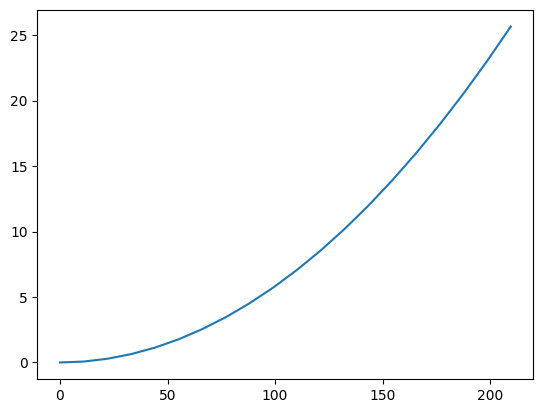

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='df-sane')

In [83]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 6.224e+01  6.224e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.058e+03  1.069e+03 ...  0.000e+00  0.000e+00]
     nit: 330
    nfev: 1000
  method: df-sane

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
# q0 = root_.x                                            # start from static solution

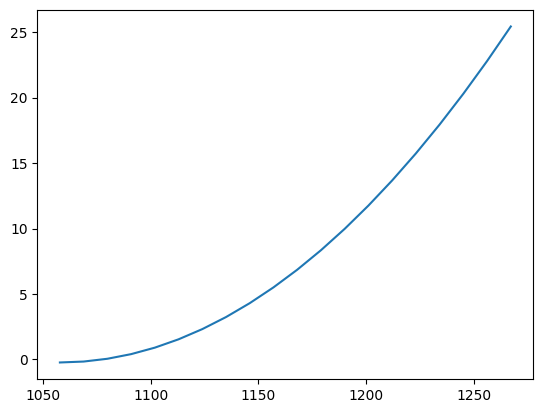

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [87]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [88]:
Number*sampleTime

600.0

In [89]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [90]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [91]:
simData.shape 

(60001, 24)

In [92]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

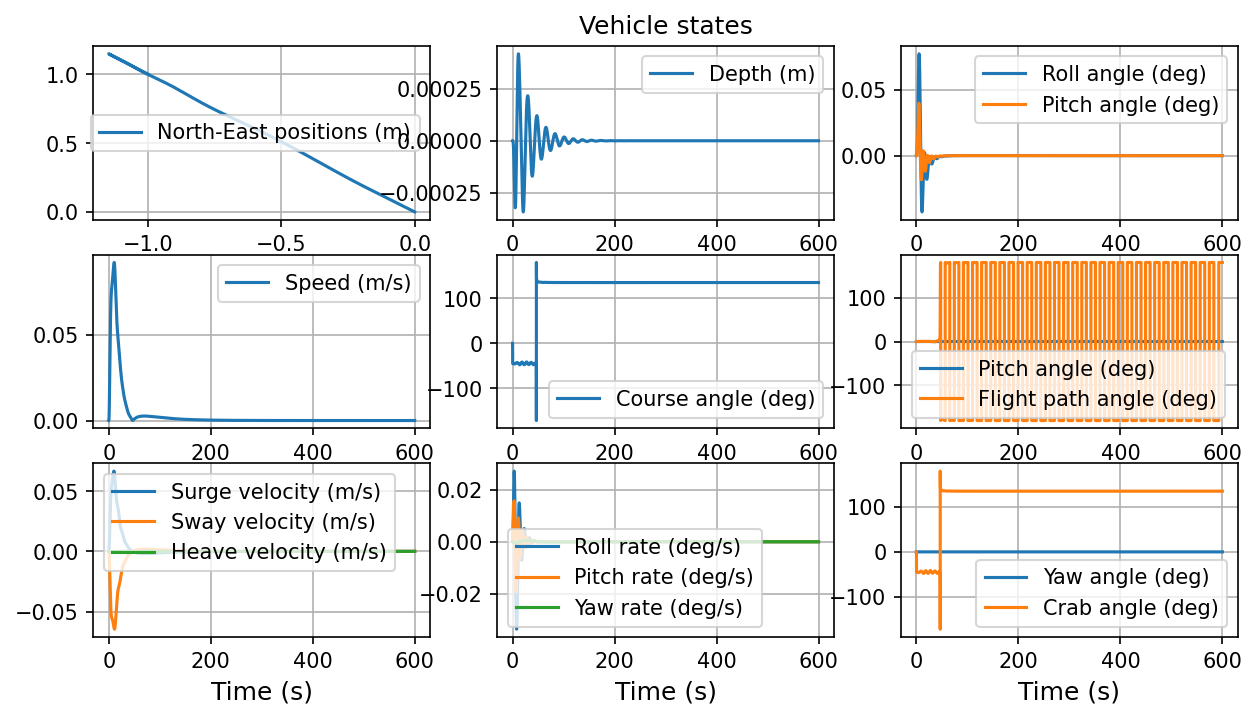

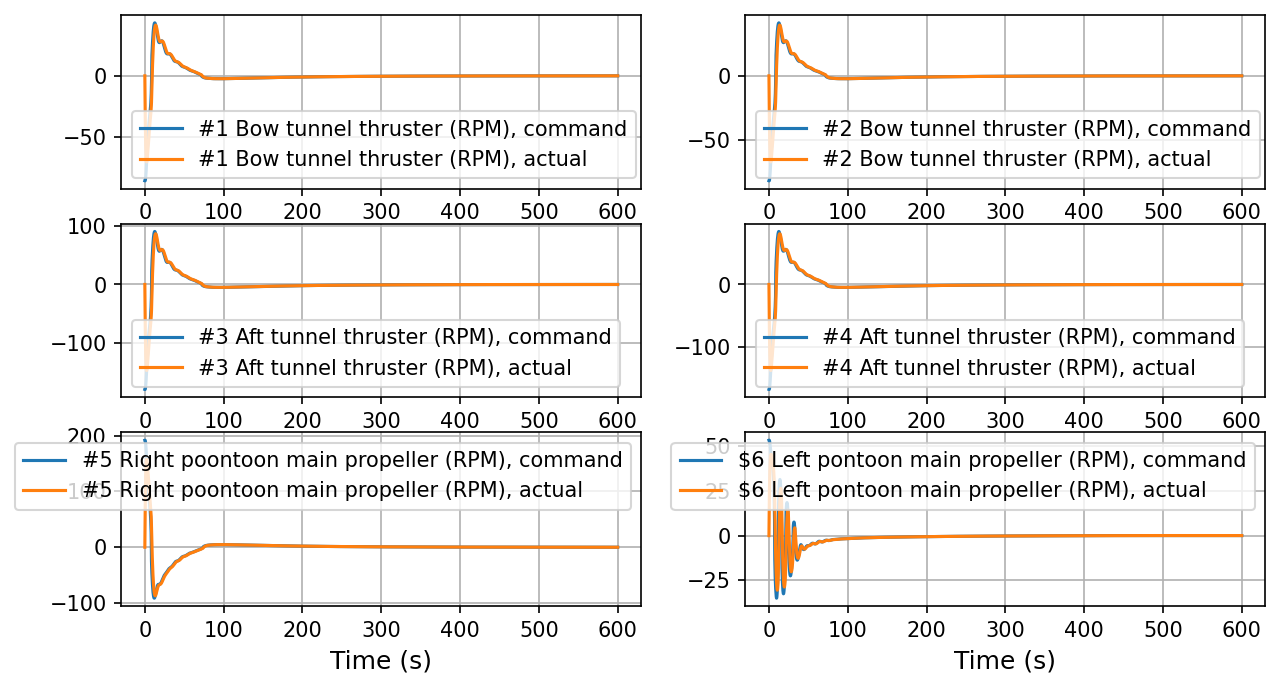

In [93]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [94]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

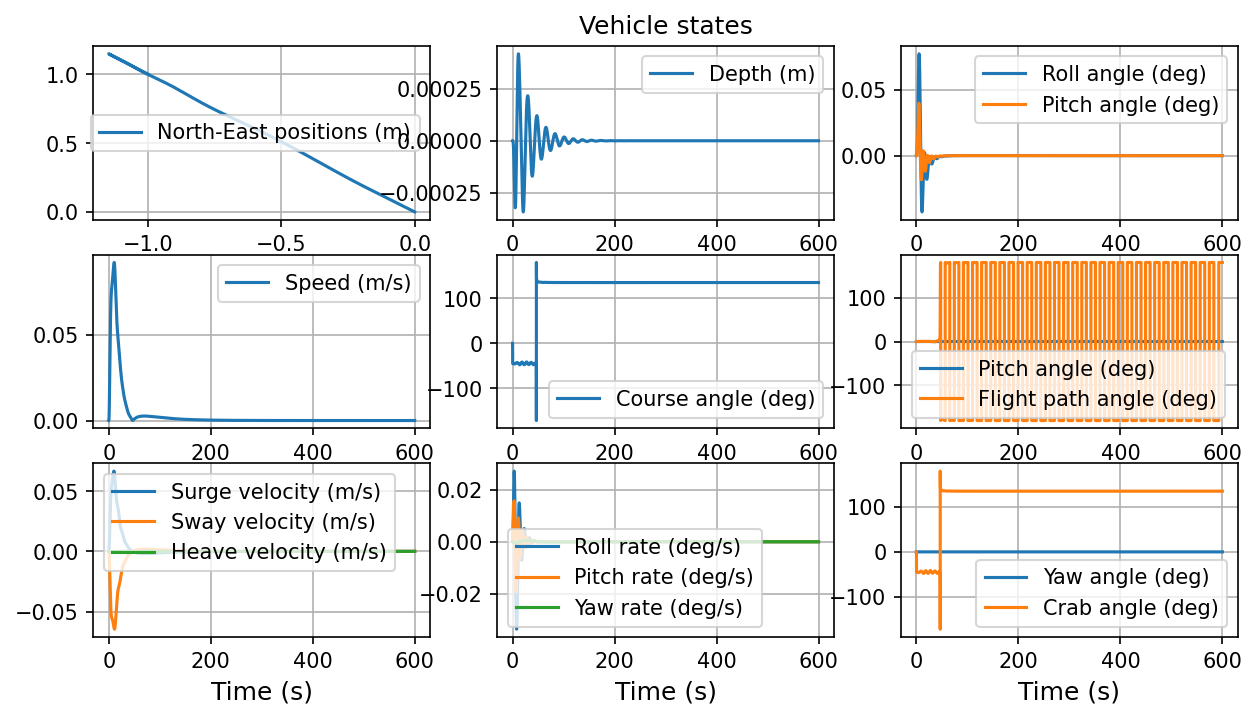

In [95]:
plotVehicleStates(simTime, simData, 3)

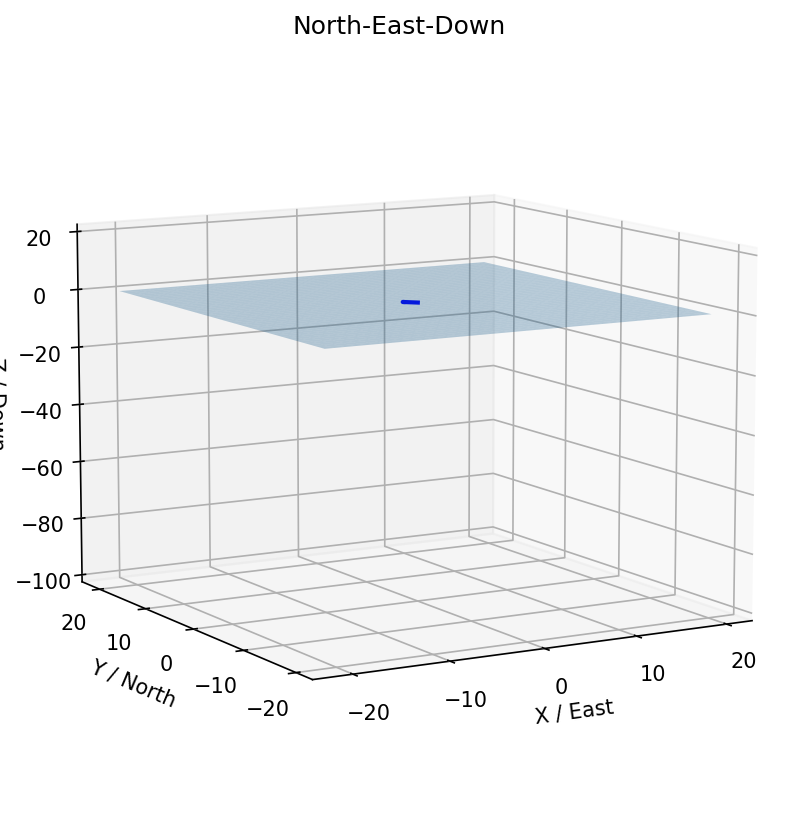

In [96]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [97]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [98]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [99]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    

    
    RET = Ret(φ,θ,ψ)
    
    
    f0=simData[:, 12][idx]
    f1=simData[:, 13][idx]
    f2=simData[:, 14][idx]
    FF1=np.sqrt((f0)**2+(f1)**2+(f2)**2) 
    
    f3=simData[:, 15][idx]
    f4=simData[:, 16][idx]
    f5=simData[:, 17][idx]
    FF2=np.sqrt((f3)**2+(f4)**2+(f5)**2) 
    
    position=np.sqrt((x)**2+(y)**2+(z)**2) 
    velocity=np.sqrt((dx)**2+(dy)**2+(dz)**2)
    
    position1=np.sqrt((φ)**2+(θ)**2+(ψ)**2)
    velocity1=np.sqrt((dφ)**2+(dθ)**2+(dψ)**2)
    
    
    Z0 = calibr*FF1*(np.tile(position, (3, 1)) + np.tile(velocity, (3, 1))).T
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T
    Z = (Z1 + Z2 - Z0 )

############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = calibr*FF2*(np.tile(position1, (3, 1)) + np.tile(velocity1, (3, 1))).T
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ).T
    C = (C1 - C0)

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################


    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [100]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.00003 for i in range(N)]),
                                          np.array([0.001267*i/N for i in range(N)]))

In [101]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.30474327017784e-08  Iteration wall-clock time:  0:00:00.013484
Physical time:  1.0120055963442556  Iteration wall-clock time:  0:00:00.813441
Physical time:  2.004945092785456  Iteration wall-clock time:  0:00:01.014468
Physical time:  3.000855170059213  Iteration wall-clock time:  0:00:01.000230
Physical time:  4.016909919353858  Iteration wall-clock time:  0:00:00.900316
Physical time:  5.003729167410364  Iteration wall-clock time:  0:00:00.919402
Physical time:  6.001949747754717  Iteration wall-clock time:  0:00:00.921433
Physical time:  7.007966440782239  Iteration wall-clock time:  0:00:00.989425
Physical time:  8.011787106745578  Iteration wall-clock time:  0:00:00.906044
Physical time:  9.000610009857935  Iteration wall-clock time:  0:00:00.922599
0:00:09.281750


In [102]:
# max axial tension
T_.top_tension

320269.9829916869

In [103]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.00012576180122002143

### Results

In [104]:
fin=us_

In [105]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.305e-06 ...  9.955e+00  1.000e+01]
        y: [[ 0.000e+00 -2.377e-22 ...  2.940e-03  2.972e-03]
            [ 1.103e+01  1.103e+01 ...  1.066e+01  1.065e+01]
            ...
            [ 0.000e+00 -1.230e-13 ... -6.954e-08 -6.975e-08]
            [ 0.000e+00 -1.231e-13 ... -6.960e-08 -6.980e-08]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1628
     njev: 0
      nlu: 0

In [106]:
t=fin.t

In [107]:
fin=fin.y.T

In [108]:
t.shape, fin.shape

((212,), (212, 240))

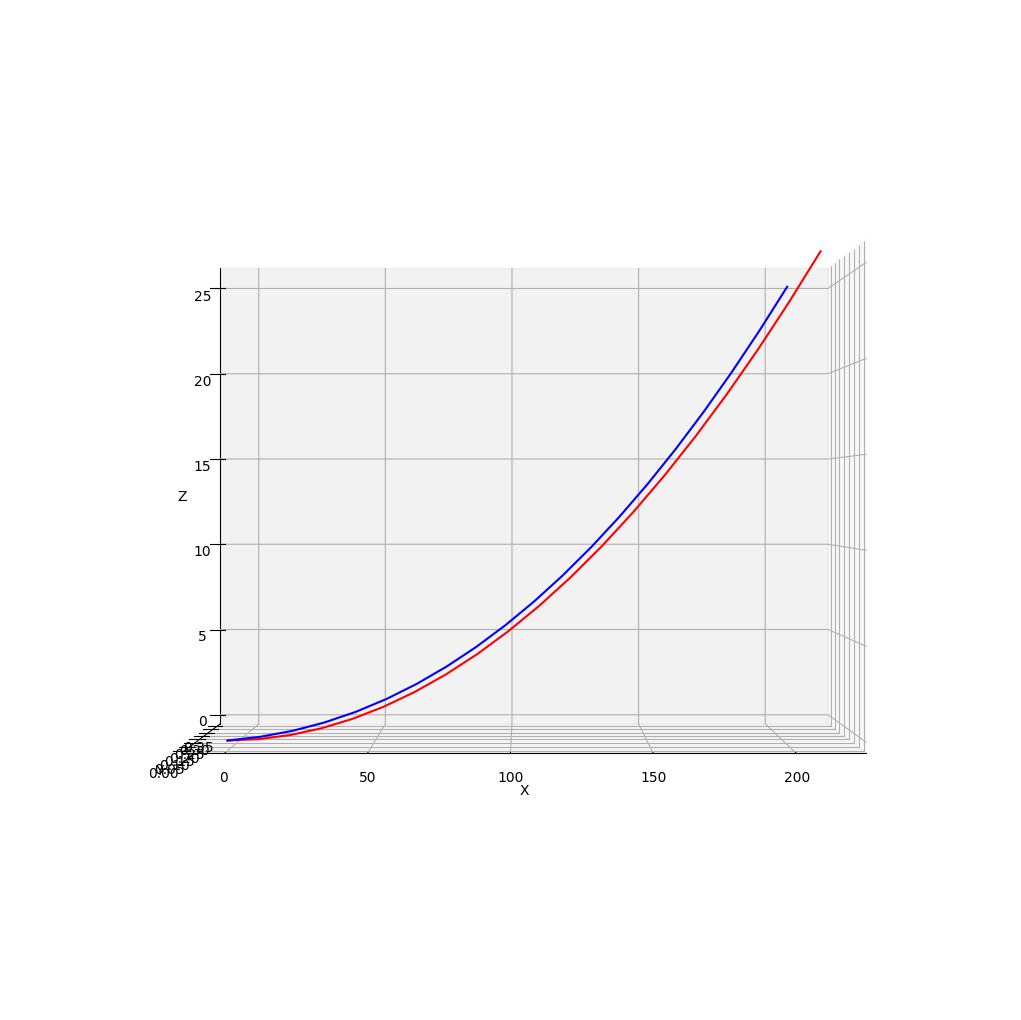

In [109]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [110]:
X,Y,Z

(array([2.97163630e-03, 1.06544300e+01, 2.14208275e+01, 3.22406300e+01,
        4.30933734e+01, 5.39700737e+01, 6.48663251e+01, 7.57800361e+01,
        8.67103720e+01, 9.76573831e+01, 1.08621577e+02, 1.19603622e+02,
        1.30603746e+02, 1.41621231e+02, 1.52653647e+02, 1.63697407e+02,
        1.74748641e+02, 1.85803744e+02, 1.96859830e+02, 2.07914891e+02]),
 array([8.65689442e-06, 3.40940740e-02, 6.36759021e-02, 9.18598086e-02,
        1.18693519e-01, 1.44169809e-01, 1.68278314e-01, 1.91010054e-01,
        2.12357437e-01, 2.32314523e-01, 2.50876834e-01, 2.68041447e-01,
        2.83806689e-01, 2.98171753e-01, 3.11135580e-01, 3.22699332e-01,
        3.32868143e-01, 3.41650439e-01, 3.49058468e-01, 3.55100723e-01]),
 array([-4.36025847e-03,  6.35000795e-02,  2.66634916e-01,  6.07100126e-01,
         1.08545985e+00,  1.70207241e+00,  2.45723355e+00,  3.35122814e+00,
         4.38435186e+00,  5.55693066e+00,  6.86932212e+00,  8.32190905e+00,
         9.91505870e+00,  1.16490665e+01,  1.352

In [111]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [112]:
us=fin.T

In [113]:
us.shape

(240, 212)

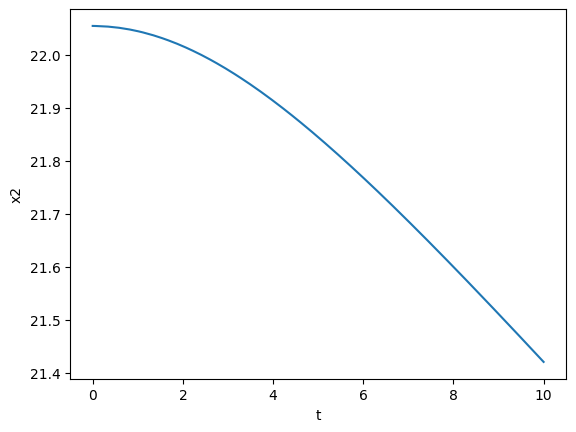

In [114]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

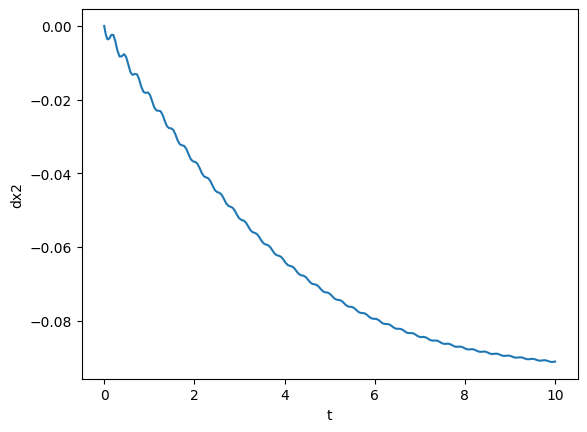

In [115]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

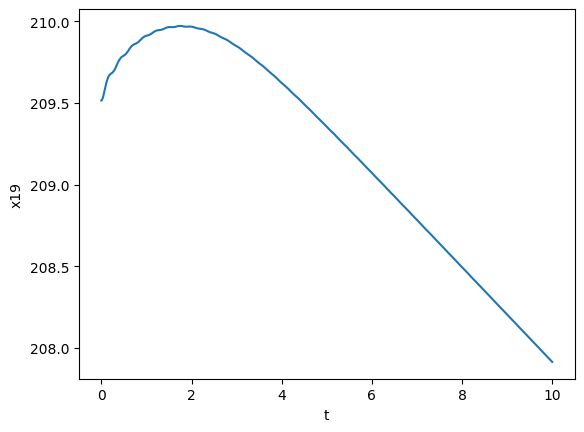

In [116]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

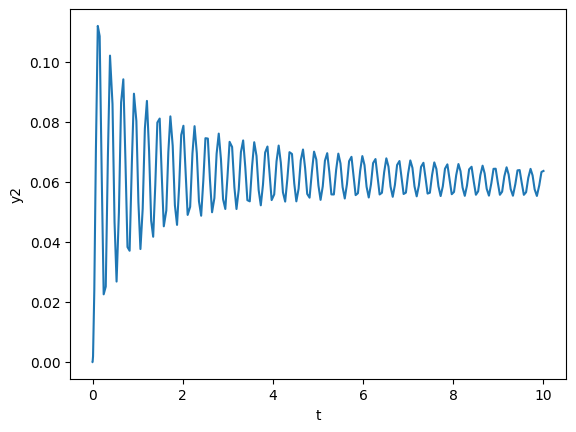

In [117]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

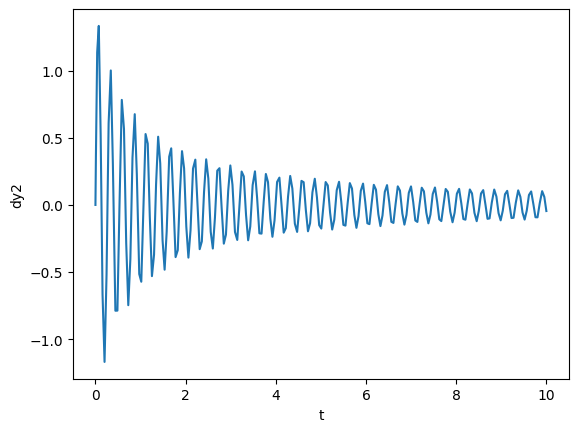

In [118]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

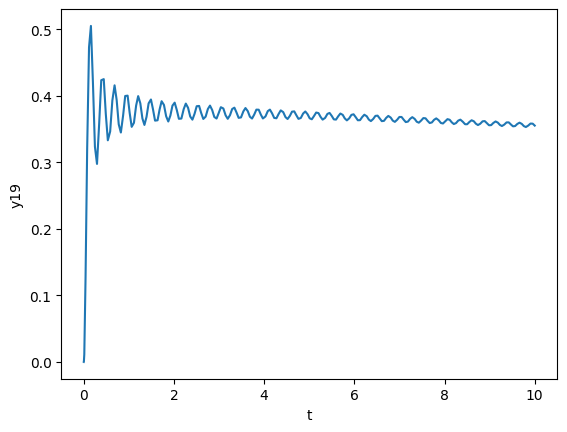

In [119]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

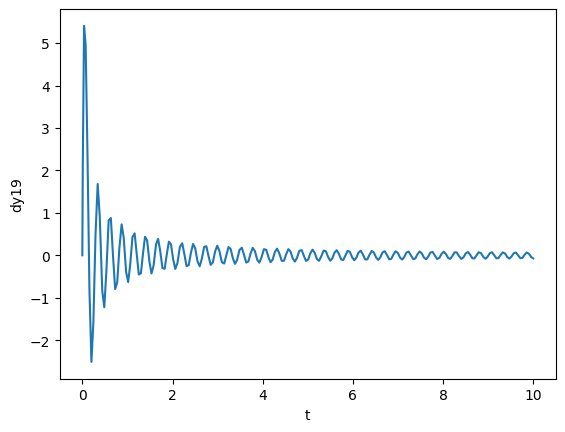

In [120]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

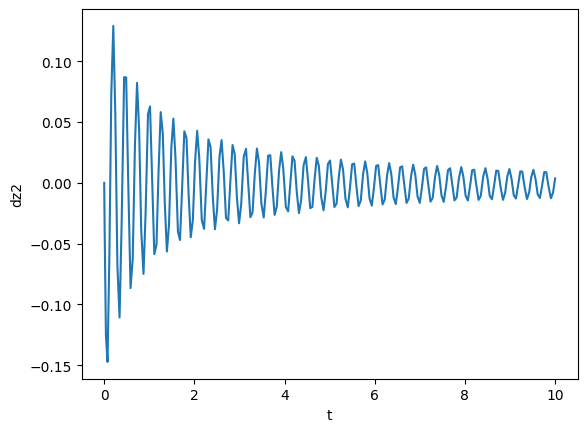

In [121]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

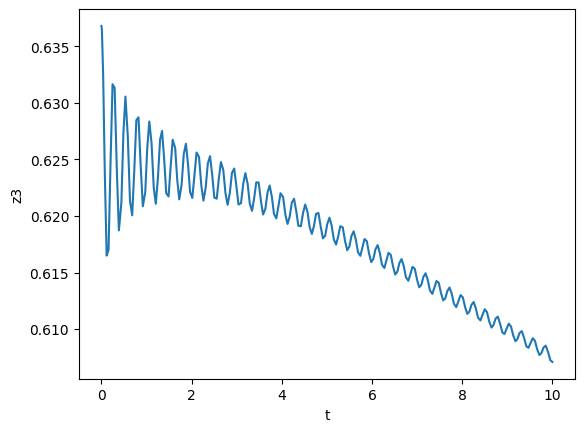

In [122]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

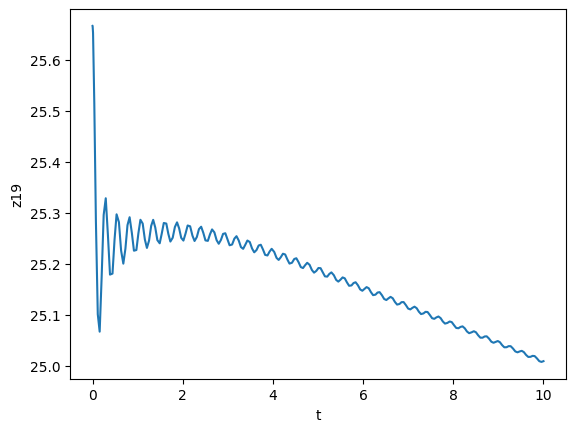

In [123]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

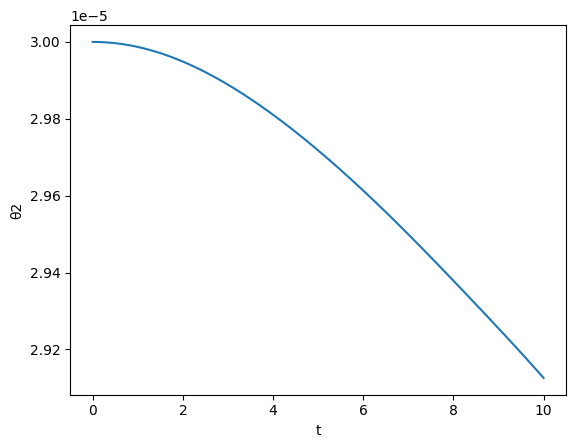

In [124]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

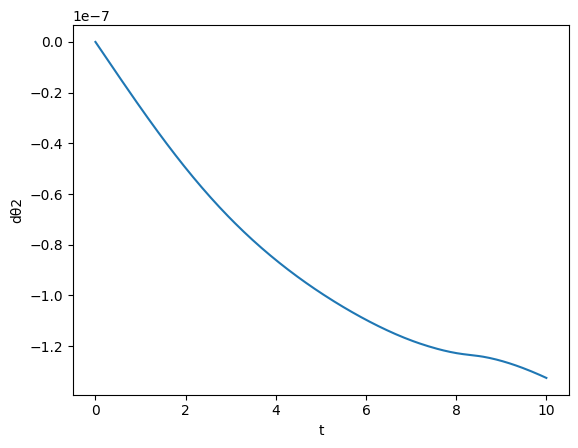

In [125]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

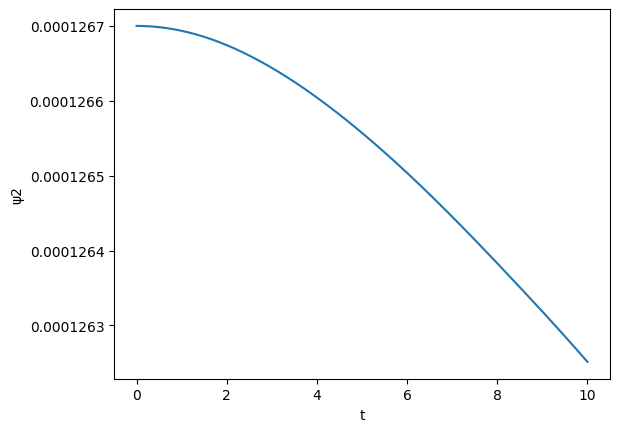

In [126]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

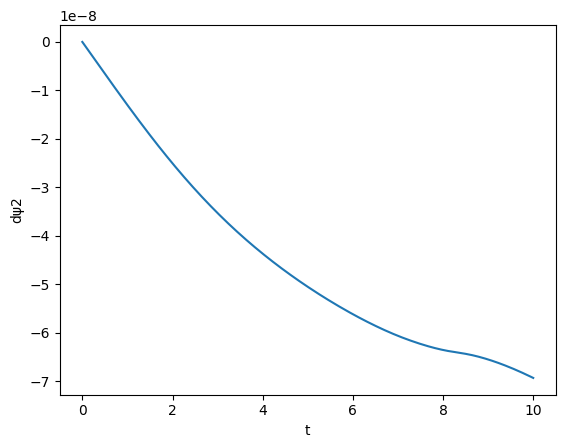

In [127]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

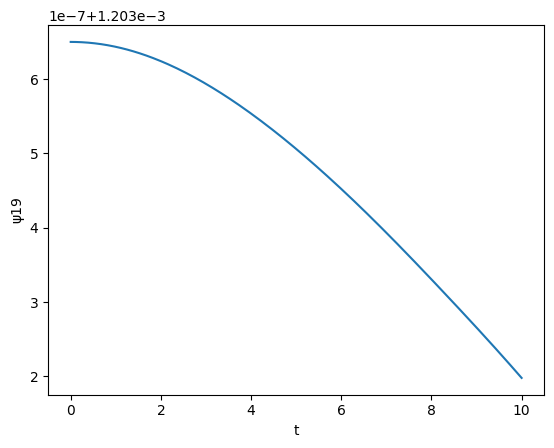

In [128]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [129]:
X010=us.T[:,0*N:1*N]

In [130]:
Y010=us.T[:,2*N:3*N]

In [131]:
Z010=us.T[:,4*N:5*N]

In [132]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()